In [1]:
import pdb
import os
from simstack4.wrapper import SimstackWrapper

In [2]:
file_date = '20250620_174427'
file_config = 'cosmos25_luv_beta.toml'

In [3]:
file_date = '20250620_172457'
file_config = 'cosmos25.toml'

In [4]:
file_date = '20250621_124530'
file_date = '20250621_143620'
file_config = 'cosmos25_luv_beta.toml'
output_file = f'sed_grid_luv_beta_{file_date}.png'

In [5]:
path_json = os.path.join(os.environ['PICKLESPATH'],'simstack','stacked_flux_densities')
file_json = f"cosmos25_stacking_{file_date}.json"

In [6]:
# Load and inspect
wrapper = SimstackWrapper(
    config=f"../config/{file_config}"
)
wrapper.load_stacking_results(os.path.join(path_json,file_json))

# Check what we actually have
print("Stacking results attributes:")
if wrapper.stacking_results:
    print(dir(wrapper.stacking_results))
    for attr in dir(wrapper.stacking_results):
        if not attr.startswith('_'):
            value = getattr(wrapper.stacking_results, attr)
            #print(f"  {attr}: {type(value)} - {value}")

print("\nPopulation manager:")
print(f"  Type: {type(wrapper.population_manager)}")
print(f"  Length: {len(wrapper.population_manager) if wrapper.population_manager else 0}")

2025-06-21 19:08:27,932 - simstack4 - INFO - SimstackWrapper initialized
2025-06-21 19:08:27,933 - simstack4 - INFO - ✓ Stacking results loaded from JSON: /Users/mviero/data/Astronomy/pickles/simstack/stacked_flux_densities/cosmos25_stacking_20250621_143620.json
2025-06-21 19:08:27,934 - simstack4 - INFO -   - 0 populations
Stacking results attributes:
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'chi_squared', 'degrees_of_freedom', 'execution_time', 'flux_densities', 'flux_errors', 'map_names', 'memory_used_gb', 'n_sources', 'population_labels', 'reduced_chi_squared']

Population manager:
  Type: <class 'NoneType'>
  Length: 0


In [7]:
wrapper.stacking_results.flux_densities.keys()

dict_keys(['mips_24', 'pacs_green', 'pacs_red', 'spire_psw', 'spire_pmw', 'spire_plw', 'scuba'])

In [8]:
wrapper.stacking_results.flux_densities['spire_psw'][:5]

[0.0001463123241366958,
 0.006999934863872834,
 0.011390764326049657,
 0.014429094945419678,
 0.01046507518215079]

In [9]:
wrapper.run_analysis_only()

2025-06-21 19:08:27,944 - simstack4 - INFO - Loading catalog...
2025-06-21 19:08:27,945 - simstack4 - INFO - SkyCatalogs initialized with polars backend
2025-06-21 19:08:27,946 - simstack4 - INFO - Loading catalog: /Users/mviero/data/Astronomy/catalogs/cosmos/COSMOSWeb_clean.parquet
2025-06-21 19:08:28,067 - simstack4 - INFO - No population splitting - all sources in single population type
2025-06-21 19:08:28,092 - simstack4 - INFO - Using single dust law: calzetti
2025-06-21 19:08:28,097 - simstack4 - WARNING - Found 5599 sources with invalid E(B-V)
2025-06-21 19:08:28,098 - simstack4 - INFO - β_UV calculation: 784,016 valid sources
2025-06-21 19:08:28,100 - simstack4 - INFO - β_UV range: -2.30 to 3.02
2025-06-21 19:08:28,106 - simstack4 - INFO - Median β_UV: -1.86
2025-06-21 19:08:28,107 - simstack4 - INFO - Added calculated column: calculated_beta_uv
2025-06-21 19:08:28,108 - simstack4 - INFO - No splitting applied - all sources in single population type
2025-06-21 19:08:28,111 - si

In [10]:
wrapper.processed_results.print_results_summary();

=== Simstack4 Results Summary ===
Processed 135 populations
Bands: 7
Greybody fitting: β fixed = 1.8

Greybody Fit Success Rate: 107/135 (79.3%)
Rest-frame temperature range: 18.1 - 104.1 K (median: 38.1 K)
Observed-frame temperature range: 8.0 - 26.2 K (median: 13.6 K)
χ²_red range: 28735.13 - 2537682189009050.50 (median: 2073982742.27)

Fit Quality:
  mips_24 (24.0μm): χ²_red = 21.74
  pacs_green (100.0μm): χ²_red = 0.18
  pacs_red (160.0μm): χ²_red = 192761.22
  spire_psw (250.0μm): χ²_red = 9.27
  spire_pmw (350.0μm): χ²_red = 6.12
  spire_plw (500.0μm): χ²_red = 2.38
  scuba (850.0μm): χ²_red = 0.00

Population Results:
Population                     N_src    z_med    T_rest[K]  T_obs[K]   L_IR[L☉]     SFR[M☉/yr]  
--------------------------------------------------------------------------------------------------------------
beta_uv_-2.5_-2.0__l_uv_9.0_1  172      0.21     31.2       25.8       1.26e+06     0.0         
beta_uv_-2.0_-1.5__l_uv_9.0_1  451      0.34     24.4       18

In [12]:
# =============================================================================
# GENERALIZED SED GRID PLOT FOR SIMSTACK4 WRAPPER RESULTS
# Supports both population types and no population types
# Uses actual fitted parameters from wrapper.processed_results
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
import seaborn as sns

def create_sed_grid_plot(wrapper, 
                         show_errors=True,
                         figsize=None,
                         max_panels=None,
                         save_path=None):
    """
    Create grid plot of SEDs (flux density vs wavelength) from SimstackWrapper results
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with stacking_results and processed_results
    show_errors : bool
        Whether to show error bars
    figsize : tuple or None
        Figure size (width, height). If None, auto-calculated
    max_panels : int or None
        Maximum number of panels to show (for large grids)
    save_path : str or Path or None
        Path to save the figure (PDF, PNG, etc. based on extension)
    """
    
    # Get results from wrapper
    if not hasattr(wrapper, 'stacking_results') or wrapper.stacking_results is None:
        print("❌ No stacking results found in wrapper")
        return None
        
    if not hasattr(wrapper, 'processed_results') or wrapper.processed_results is None:
        print("❌ No processed results found in wrapper")
        return None
    
    stacking_results = wrapper.stacking_results
    processed_results = wrapper.processed_results
    
    # Get summary dataframe
    try:
        if hasattr(processed_results, 'get_population_summary'):
            summary_df = processed_results.get_population_summary()
        else:
            # Fallback to population manager
            summary_df = wrapper.population_manager.get_population_summary()
        
        print(f"📋 Available columns: {list(summary_df.columns)}")
        
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    # Extract wavelengths from map names
    map_names = stacking_results.map_names
    wavelengths = []
    
    for map_name in map_names:
        if 'mips_24' in map_name or '24' in map_name:
            wavelengths.append(24.0)
        elif 'pacs_green' in map_name or '100' in map_name:
            wavelengths.append(100.0)
        elif 'pacs_red' in map_name or '160' in map_name:
            wavelengths.append(160.0)
        elif 'spire_psw' in map_name or '250' in map_name:
            wavelengths.append(250.0)
        elif 'spire_pmw' in map_name or '350' in map_name:
            wavelengths.append(350.0)
        elif 'spire_plw' in map_name or '500' in map_name:
            wavelengths.append(500.0)
        elif 'scuba' in map_name or '850' in map_name:
            wavelengths.append(850.0)
        else:
            # Try to extract number from name
            import re
            numbers = re.findall(r'\d+', map_name)
            if numbers:
                wavelengths.append(float(numbers[0]))
            else:
                wavelengths.append(len(wavelengths) * 100)  # Fallback
    
    wavelengths = np.array(wavelengths)
    print(f"📡 Available wavelengths: {wavelengths} μm")
    print(f"📊 Map names: {map_names}")
    
    # Filter for detected populations only
    df = summary_df.copy()
    
    # Check if we have L_IR measurements
    lir_cols = [col for col in df.columns if 'ir_luminosity' in col.lower()]
    if lir_cols:
        lir_col = lir_cols[0]
        df = df[df[lir_col] > 0]
        print(f"🔍 Using {lir_col} for detection filter")
    else:
        # Fallback: use number of sources
        df = df[df['n_sources'] > 0]
        print("🔍 Using n_sources > 0 for detection filter")
    
    if len(df) == 0:
        print("❌ No detected populations found")
        return None
    
    print(f"✅ Found {len(df)} detected populations")
    
    # Parse population information to create grid
    def parse_population_id(pop_id):
        """Extract binning information from population ID"""
        try:
            parts = pop_id.split('__')
            bin_info = {}
            
            for part in parts:
                if '_' in part:
                    # Look for patterns like "redshift_0.5_1.0" or "l_uv_9.0_10.0"
                    elements = part.split('_')
                    if len(elements) >= 3:
                        # Try to find numeric ranges
                        try:
                            # Check if last two elements are numbers
                            min_val = float(elements[-2])
                            max_val = float(elements[-1])
                            bin_name = '_'.join(elements[:-2])
                            bin_info[bin_name] = (min_val, max_val)
                        except ValueError:
                            continue
            
            return bin_info
        except Exception as e:
            print(f"⚠️  Could not parse population ID: {pop_id}")
            return {}
    
    # Determine the correct population ID column name
    pop_id_col = None
    possible_id_cols = ['id_label', 'population_id', 'pop_id', 'label']
    
    for col in possible_id_cols:
        if col in df.columns:
            pop_id_col = col
            break
    
    if pop_id_col is None:
        print(f"❌ Could not find population ID column. Available columns: {list(df.columns)}")
        return None
    
    print(f"🏷️  Using population ID column: '{pop_id_col}'")
    
    # Parse all population IDs
    parsed_info = df[pop_id_col].apply(parse_population_id)
    
    # Find the most common binning dimensions
    all_bin_names = set()
    for info in parsed_info:
        all_bin_names.update(info.keys())
    
    print(f"🗂️  Detected binning dimensions: {list(all_bin_names)}")
    
    if len(all_bin_names) < 2:
        print("⚠️  Less than 2 binning dimensions found, creating simple plot")
        return create_simple_sed_plot(df, stacking_results, wavelengths, map_names, show_errors, pop_id_col)
    
    # Choose two primary dimensions for the grid
    # Priority: redshift, stellar_mass, l_uv, beta_uv
    priority_dims = ['redshift', 'stellar_mass', 'l_uv', 'beta_uv', 'mass', 'z']
    
    primary_dims = []
    for dim in priority_dims:
        matches = [name for name in all_bin_names if dim in name.lower()]
        if matches:
            primary_dims.extend(matches[:2])  # Take up to 2 matches
            if len(primary_dims) >= 2:
                break
    
    # If we still don't have 2 dimensions, take the first 2
    if len(primary_dims) < 2:
        primary_dims = list(all_bin_names)[:2]
    
    dim1, dim2 = primary_dims[0], primary_dims[1]
    print(f"📐 Grid dimensions: {dim1} (x-axis) × {dim2} (y-axis)")
    
    # Extract bin values for each dimension
    def get_bin_values(dim_name):
        values = []
        for info in parsed_info:
            if dim_name in info:
                min_val, max_val = info[dim_name]
                values.append((min_val, max_val))
        return sorted(list(set(values)))
    
    dim1_bins = get_bin_values(dim1)
    dim2_bins = get_bin_values(dim2)
    
    print(f"📊 Grid size: {len(dim1_bins)} × {len(dim2_bins)} = {len(dim1_bins) * len(dim2_bins)} panels")
    
    # Check if grid is too large
    if max_panels and len(dim1_bins) * len(dim2_bins) > max_panels:
        print(f"⚠️  Grid too large ({len(dim1_bins) * len(dim2_bins)} panels), truncating to {max_panels}")
        dim1_bins = dim1_bins[:int(np.sqrt(max_panels))]
        dim2_bins = dim2_bins[:int(np.sqrt(max_panels))]
    
    # Calculate figure size
    if figsize is None:
        figsize = (len(dim1_bins) * 2.8, len(dim2_bins) * 2.5)
    
    # Create the plot
    fig, axes = plt.subplots(len(dim2_bins), len(dim1_bins), figsize=figsize, 
                           sharex=True, sharey=True)
    
    # Handle single row/column cases
    if len(dim1_bins) == 1 and len(dim2_bins) == 1:
        axes = np.array([[axes]])
    elif len(dim1_bins) == 1:
        axes = axes.reshape(-1, 1)
    elif len(dim2_bins) == 1:
        axes = axes.reshape(1, -1)
    
    # Color scheme - try to detect population types
    has_split = any('split' in str(pop_id) for pop_id in df[pop_id_col])
    
    if has_split:
        color_map = {
            'split_0': '#FF6B6B',  # Star-forming (red)
            'split_1': '#4ECDC4',  # Quiescent (teal)
        }
        default_color = '#45B7D1'  # Blue
    else:
        default_color = '#45B7D1'  # Blue for all
    
    # Track panels with multiple populations for colorbar
    panels_with_multiple_pops = []
    max_pops_in_panel = 1
    
    # Plot each panel
    for i, dim2_bin in enumerate(dim2_bins):
        for j, dim1_bin in enumerate(dim1_bins):
            if len(dim2_bins) == 1 and len(dim1_bins) == 1:
                ax = axes[0, 0]
            elif len(dim2_bins) == 1:
                ax = axes[0, j]
            elif len(dim1_bins) == 1:
                ax = axes[i, 0]
            else:
                ax = axes[i, j]
            
            # Find populations for this bin
            pop_matches = []
            for idx, info in enumerate(parsed_info):
                if (dim1 in info and info[dim1] == dim1_bin and 
                    dim2 in info and info[dim2] == dim2_bin):
                    pop_matches.append(idx)
            
            if len(pop_matches) == 0:
                # No data for this bin
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=12, alpha=0.5)
                ax.set_xlim(11, 1000)
                ax.set_ylim(1e-3, 1e2)
            else:
                # Track max populations for colorbar
                max_pops_in_panel = max(max_pops_in_panel, len(pop_matches))
                
                # Create color spectrum if multiple populations
                if len(pop_matches) > 1:
                    # Use a colormap for multiple populations
                    import matplotlib.cm as cm
                    colors_for_panel = cm.viridis(np.linspace(0, 1, len(pop_matches)))
                    panels_with_multiple_pops.append((i, j, len(pop_matches)))
                else:
                    colors_for_panel = None
                
                # Collect legend entries for this panel
                legend_entries = []
                
                # Plot SEDs for all populations in this bin
                for pop_idx_in_panel, pop_idx in enumerate(pop_matches):
                    pop = df.iloc[pop_idx]
                    pop_id = pop[pop_id_col]
                    
                    # Get color for this population
                    if len(pop_matches) > 1 and colors_for_panel is not None:
                        # Use color spectrum
                        color = colors_for_panel[pop_idx_in_panel]
                    elif has_split:
                        if 'split_0' in str(pop_id):
                            color = color_map['split_0']
                        elif 'split_1' in str(pop_id):
                            color = color_map['split_1']
                        else:
                            color = default_color
                    else:
                        color = default_color
                    
                    # Get L_IR for legend
                    l_ir = pop.get('total_ir_luminosity_lsun', 0)
                    if l_ir > 0:
                        #log_l_ir = np.log10(l_ir)
                        log_l_ir = l_ir
                        legend_label = f"LIR/L☉={log_l_ir:.2f}"
                    else:
                        legend_label = "No L_IR"
                    
                    legend_entries.append((color, legend_label))
                    pop = df.iloc[pop_idx]
                    pop_id = pop[pop_id_col]
                    
                    # Color is already determined above
                    
                    # Get flux measurements
                    try:
                        # Handle both list and numpy array cases
                        if hasattr(stacking_results.population_labels, 'index'):
                            result_pop_idx = stacking_results.population_labels.index(pop_id)
                        else:
                            # Convert to list if it's a numpy array
                            pop_labels_list = list(stacking_results.population_labels)
                            result_pop_idx = pop_labels_list.index(pop_id)
                        
                        fluxes = []
                        flux_errors = []
                        
                        for map_name in map_names:
                            flux = stacking_results.flux_densities[map_name][result_pop_idx] * 1e3  # Convert to mJy
                            flux_err = stacking_results.flux_errors[map_name][result_pop_idx] * 1e3
                            fluxes.append(flux)
                            flux_errors.append(flux_err)
                        
                        fluxes = np.array(fluxes)
                        flux_errors = np.array(flux_errors)
                        
                        # Plot detected points (positive flux) - CIRCLES ONLY
                        detected_mask = fluxes > 0
                        
                        if np.any(detected_mask):
                            if show_errors and np.any(flux_errors[detected_mask] > 0):
                                ax.errorbar(wavelengths[detected_mask], fluxes[detected_mask], 
                                          yerr=flux_errors[detected_mask],
                                          fmt='o', color=color, alpha=0.8, 
                                          markersize=6, capsize=2, linewidth=1.5)
                            else:
                                ax.plot(wavelengths[detected_mask], fluxes[detected_mask], 
                                      'o', color=color, alpha=0.8, markersize=6)
                            
                            # PLOT SED MODEL using results.py functions
                            try:
                                # Check what's available in processed_results
                                if hasattr(wrapper.processed_results, 'sed_results'):
                                    if pop_id in wrapper.processed_results.sed_results:
                                        sed_fit = wrapper.processed_results.sed_results[pop_id]
                                        
                                        # Check if we have the required attributes
                                        amplitude = getattr(sed_fit, 'amplitude', None)
                                        temperature = getattr(sed_fit, 'dust_temperature_observed_frame', None)
                                        beta = getattr(sed_fit, 'emissivity_index', 1.8) or 1.8
                                        
                                        if amplitude is not None and temperature is not None:
                                            # Generate model SED curve using results.py greybody_model
                                            model_wavelengths = np.logspace(1, 3, 50)  # Fewer points for speed
                                            
                                            # Use the actual greybody_model from results.py
                                            model_fluxes = wrapper.processed_results.greybody_fitter.greybody_model(
                                                model_wavelengths, amplitude, temperature, beta
                                            )
                                            
                                            # Plot model curve - CONVERT TO mJy
                                            ax.plot(model_wavelengths, model_fluxes * 1e3, '-', 
                                                   color=color, alpha=0.6, linewidth=2, zorder=1)
                                
                            except Exception as e:
                                print(f"❌ Error plotting SED model for {pop_id}: {e}")
                                pass  # Continue without SED model
                        
                        # Plot upper limits for non-detected points - CONVERT TO mJy
                        nondet_mask = (fluxes <= 0) | (fluxes < 2 * flux_errors)
                        if np.any(nondet_mask):
                            upper_limits = np.maximum(2 * flux_errors[nondet_mask], 0.1)
                            ax.plot(wavelengths[nondet_mask], upper_limits, 
                                  'v', color=color, alpha=0.4, markersize=3)
                        
                    except (ValueError, IndexError) as e:
                        print(f"⚠️  Could not find flux data for {pop_id}: {e}")
                        continue
                
                # Add single legend for this panel with all populations
                if legend_entries:
                    from matplotlib.lines import Line2D
                    legend_lines = []
                    legend_labels = []
                    
                    for color, label in legend_entries[::-1]:
                        legend_lines.append(Line2D([0], [0], color=color, linewidth=2))
                        legend_labels.append(label)
                    
                    ax.legend(legend_lines, legend_labels, loc='upper left', 
                             fontsize=8, frameon=True, fancybox=True, 
                             framealpha=0.8, edgecolor='gray')
            
            # Set log scales
            ax.set_xscale('log')
            ax.set_yscale('log')
            
            # Set limits
            #ax.set_xlim(np.min(wavelengths) * 0.8, np.max(wavelengths) * 1.2)
            ax.set_xlim(11, np.max(wavelengths) * 1.2)
            ax.set_ylim(1e-2, 1e3)
            
            # Grid
            ax.grid(True, alpha=0.3)
            
            # Labels for edge panels
            if i == len(dim2_bins) - 1:  # Bottom row
                ax.set_xlabel('Observed Wavelength (μm)', fontsize=12)
            if j == 0:  # Left column
                ax.set_ylabel('Flux Density (mJy)', fontsize=12)
            
            # Make tick labels bigger
            ax.tick_params(axis='both', which='major', labelsize=12)
            
            # Title for top row
            if i == 0:
                dim1_min, dim1_max = dim1_bin
                title = f"{dim1.replace('_', ' ')}: {dim1_min:.1f}-{dim1_max:.1f}"
                ax.set_title(title, fontsize=12)
            
            # Labels on right
            if j == len(dim1_bins) - 1:
                dim2_min, dim2_max = dim2_bin
                label = f"{dim2.replace('_', ' ')}: {dim2_min:.1f}-{dim2_max:.1f}"
                
                ax2 = ax.twinx()
                ax2.set_ylabel(label, rotation=270, labelpad=20, fontsize=12)
                ax2.set_yticks([])
    
    plt.tight_layout()
    
    # Add colorbar based on what we found
    if len(panels_with_multiple_pops) > 0:
        # Adjust layout to make room for colorbar
        plt.subplots_adjust(top=0.92, hspace=0.02, wspace=0.02, right=0.88)
        
        # Create colorbar for color spectrum
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize
        
        # Use viridis colormap
        norm = Normalize(vmin=0, vmax=max_pops_in_panel-1)
        sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm)
        sm.set_array([])
        
        # Add colorbar
        cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02, aspect=30)
        cbar.set_label('Beta_UV', fontsize=12)
        cbar.ax.tick_params(labelsize=12)
        
    elif has_split:
        # No colorbar needed, just adjust layout
        plt.subplots_adjust(top=0.92, hspace=0.02, wspace=0.02)
    else:
        # No colorbar needed, just adjust layout
        plt.subplots_adjust(top=0.95, hspace=0.02, wspace=0.02)
    
    # Add overall title
    title = f"SED Grid: {len(df)} detected populations"
    if has_split and len(panels_with_multiple_pops) == 0:
        title += " (Red: SF, Teal: Q)"
    fig.suptitle(title, fontsize=12)
    
    # Save figure if path provided
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            # Determine DPI based on file format
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Figure saved to: {save_path}")
            
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    return fig

def create_simple_sed_plot(df, stacking_results, wavelengths, map_names, show_errors, pop_id_col):
    """
    Create simple SED plot when grid layout is not possible
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(df)))
    
    for idx, (_, pop) in enumerate(df.iterrows()):
        pop_id = pop[pop_id_col]  # Use the correct column name
        color = colors[idx]
        
        try:
            # Handle both list and numpy array cases for population labels
            if hasattr(stacking_results.population_labels, 'index'):
                result_pop_idx = stacking_results.population_labels.index(pop_id)
            else:
                pop_labels_list = list(stacking_results.population_labels)
                result_pop_idx = pop_labels_list.index(pop_id)
            
            fluxes = []
            flux_errors = []
            
            for map_name in map_names:
                flux = stacking_results.flux_densities[map_name][result_pop_idx] * 1e3
                flux_err = stacking_results.flux_errors[map_name][result_pop_idx] * 1e3
                fluxes.append(flux)
                flux_errors.append(flux_err)
            
            fluxes = np.array(fluxes)
            flux_errors = np.array(flux_errors)
            
            detected_mask = fluxes > 0
            
            if np.any(detected_mask):
                label = f"{pop_id.split('__')[0]}... (N={pop['n_sources']})"
                
                if show_errors:
                    ax.errorbar(wavelengths[detected_mask], fluxes[detected_mask], 
                              yerr=flux_errors[detected_mask],
                              fmt='o-', color=color, alpha=0.8, 
                              markersize=8, capsize=3, linewidth=2, label=label)
                else:
                    ax.plot(wavelengths[detected_mask], fluxes[detected_mask], 
                          'o-', color=color, alpha=0.8, markersize=8, label=label)
        
        except (ValueError, IndexError):
            continue
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Observed Wavelength (μm)', fontsize=12)
    ax.set_ylabel('Flux Density (mJy)', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    
    plt.tight_layout()
    
    return fig

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
📡 Available wavelengths: [ 24. 100. 160. 250. 350. 500. 850.] μm
📊 Map names: ['mips_24' 'pacs_green' 'pacs_red' 'spire_psw' 'spire_pmw' 'spire_plw'
 'scuba']
🔍 Using total_ir_luminosity_lsun for detection filter
✅ Found 112 detected populations
🏷️  Using population ID column: 'population_id'
🗂️  Detected binning dimensions: ['redshift', 'beta_uv', 'l_uv']
📐 Grid dimensions: redshift (x-axis) × l_uv (y-axis)
📊 Grid size: 8 × 3 = 24 panels
💾 Figure saved to: /Users/mviero/Desktop/sed_grid_luv_beta_20250621_143620.png


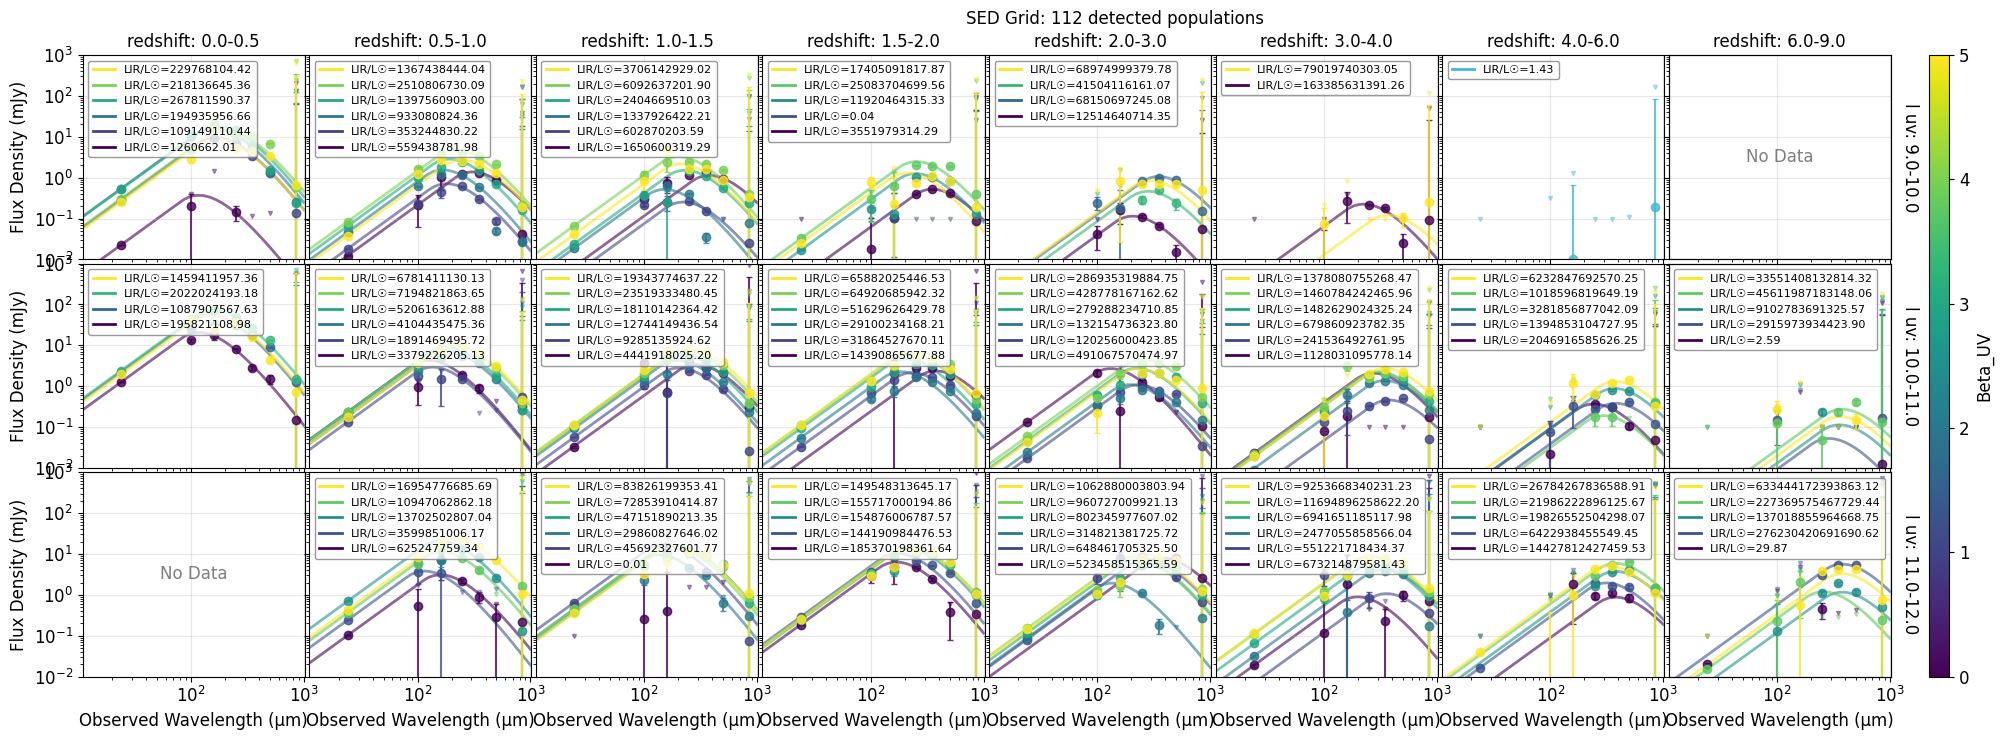

In [13]:
fig=create_sed_grid_plot(wrapper, save_path=f"/Users/mviero/Desktop/{output_file}")

In [14]:
def create_lir_luv_beta_plot(wrapper, 
                              show_errors=True,
                              figsize=(10, 8),
                              color_by='redshift',
                              average_luv=False,
                              save_path=None):
    """
    Create L_IR/L_UV vs β_UV plot from SimstackWrapper results
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with stacking_results and processed_results
    show_errors : bool
        Whether to show error bars
    figsize : tuple
        Figure size (width, height)
    color_by : str
        What to color points by: 'redshift' (default) or 'l_uv'
    average_luv : bool
        If True, average over L_UV bins (collapse L_UV dimension)
    save_path : str or Path or None
        Path to save the figure (PDF, PNG, etc. based on extension)
    """
    
    # Get results from wrapper
    if not hasattr(wrapper, 'stacking_results') or wrapper.stacking_results is None:
        print("❌ No stacking results found in wrapper")
        return None
        
    if not hasattr(wrapper, 'processed_results') or wrapper.processed_results is None:
        print("❌ No processed results found in wrapper")
        return None
    
    # Get summary dataframe
    try:
        if hasattr(wrapper.processed_results, 'get_population_summary'):
            summary_df = wrapper.processed_results.get_population_summary()
        else:
            summary_df = wrapper.population_manager.get_population_summary()
        
        print(f"📋 Available columns: {list(summary_df.columns)}")
        
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    # Determine the correct population ID column name
    pop_id_col = None
    possible_id_cols = ['id_label', 'population_id', 'pop_id', 'label']
    
    for col in possible_id_cols:
        if col in summary_df.columns:
            pop_id_col = col
            break
    
    if pop_id_col is None:
        print(f"❌ Could not find population ID column. Available columns: {list(summary_df.columns)}")
        return None
    
    # Filter for detected populations only
    df = summary_df.copy()
    
    # Check if we have L_IR measurements
    lir_cols = [col for col in df.columns if 'ir_luminosity' in col.lower()]
    if not lir_cols:
        print("❌ No L_IR measurements found")
        return None
    
    lir_col = lir_cols[0]
    df = df[df[lir_col] > 0]
    print(f"🔍 Using {lir_col} for L_IR")
    
    if len(df) == 0:
        print("❌ No detected populations found")
        return None
    
    print(f"✅ Found {len(df)} detected populations")
    
    # Parse population information to extract β_UV and L_UV
    def parse_population_id(pop_id):
        """Extract binning information from population ID"""
        try:
            parts = pop_id.split('__')
            bin_info = {}
            
            for part in parts:
                if '_' in part:
                    elements = part.split('_')
                    if len(elements) >= 3:
                        try:
                            min_val = float(elements[-2])
                            max_val = float(elements[-1])
                            bin_name = '_'.join(elements[:-2])
                            bin_info[bin_name] = (min_val, max_val)
                        except ValueError:
                            continue
            
            return bin_info
        except Exception as e:
            print(f"⚠️  Could not parse population ID: {pop_id}")
            return {}
    
    # Parse all population IDs
    parsed_info = df[pop_id_col].apply(parse_population_id)
    
    # Extract β_UV, L_UV, and redshift values
    beta_uv_values = []
    l_uv_values = []
    redshift_values = []
    l_ir_luv_ratios = []
    
    # Color scheme for population types (backup if not using colorbar)
    has_split = any('split' in str(pop_id) for pop_id in df[pop_id_col])
    
    for idx, (_, pop) in enumerate(df.iterrows()):
        pop_id = pop[pop_id_col]
        bin_info = parsed_info.iloc[idx]
        
        # Extract β_UV and redshift from binning
        beta_uv = None
        l_uv = None
        redshift = None
        
        for bin_name, (min_val, max_val) in bin_info.items():
            if 'beta' in bin_name.lower():
                beta_uv = (min_val + max_val) / 2  # Use bin center
            elif 'l_uv' in bin_name.lower() or 'luv' in bin_name.lower():
                l_uv = (min_val + max_val) / 2  # Use bin center
            elif 'redshift' in bin_name.lower() or bin_name.lower() == 'z':
                redshift = (min_val + max_val) / 2  # Use bin center
        
        # Also try to get redshift from median_redshift column
        if redshift is None and 'median_redshift' in pop:
            redshift = pop['median_redshift']
        
        # Get L_IR
        l_ir = pop[lir_col]
        
        # Only include if we have all required values
        if beta_uv is not None and l_uv is not None and l_ir > 0:
            beta_uv_values.append(beta_uv)
            l_uv_values.append(l_uv)
            redshift_values.append(redshift if redshift is not None else np.nan)
            
            # Calculate L_IR/L_UV ratio
            # L_UV is in log space, so convert: L_UV = 10^l_uv
            l_uv_linear = 10**l_uv
            l_ir_luv_ratio = np.log10(l_ir / l_uv_linear)
            l_ir_luv_ratios.append(l_ir_luv_ratio)
    
    if len(beta_uv_values) == 0:
        print("❌ No populations found with both β_UV and L_UV binning")
        return None
    
    print(f"📊 Found {len(beta_uv_values)} populations with β_UV and L_UV data")
    
    # Convert to arrays
    beta_uv_values = np.array(beta_uv_values)
    l_uv_values = np.array(l_uv_values)
    redshift_values = np.array(redshift_values)
    l_ir_luv_ratios = np.array(l_ir_luv_ratios)
    
    # Optional: Average over L_UV bins
    if average_luv:
        print("📊 Averaging over L_UV bins...")
        
        # Group by unique β_UV and redshift bins, average over L_UV
        unique_combinations = {}
        
        for i in range(len(beta_uv_values)):
            # Create key from β_UV and redshift (rounded for grouping)
            beta_key = round(beta_uv_values[i], 2)
            redshift_key = round(redshift_values[i], 2) if np.isfinite(redshift_values[i]) else 'nan'
            key = (beta_key, redshift_key)
            
            if key not in unique_combinations:
                unique_combinations[key] = {
                    'beta_uv': [],
                    'l_uv': [],
                    'redshift': [],
                    'l_ir_luv': []
                }
            
            unique_combinations[key]['beta_uv'].append(beta_uv_values[i])
            unique_combinations[key]['l_uv'].append(l_uv_values[i])
            unique_combinations[key]['redshift'].append(redshift_values[i])
            unique_combinations[key]['l_ir_luv'].append(l_ir_luv_ratios[i])
        
        # Average the grouped values
        beta_uv_avg = []
        l_uv_avg = []
        redshift_avg = []
        l_ir_luv_avg = []
        l_ir_luv_std = []
        
        for key, values in unique_combinations.items():
            beta_uv_avg.append(np.mean(values['beta_uv']))
            l_uv_avg.append(np.mean(values['l_uv']))
            redshift_avg.append(np.mean(values['redshift']))
            l_ir_luv_avg.append(np.mean(values['l_ir_luv']))
            l_ir_luv_std.append(np.std(values['l_ir_luv']) if len(values['l_ir_luv']) > 1 else 0)
        
        # Replace arrays with averaged values
        beta_uv_values = np.array(beta_uv_avg)
        l_uv_values = np.array(l_uv_avg)
        redshift_values = np.array(redshift_avg)
        l_ir_luv_ratios = np.array(l_ir_luv_avg)
        l_ir_luv_errors = np.array(l_ir_luv_std)
        
        print(f"📊 Reduced to {len(beta_uv_values)} averaged points")
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Determine what to color by
    if color_by == 'l_uv':
        color_values = l_uv_values
        color_label = 'log L_UV/L_☉'
        cmap = 'viridis'
    else:  # default to redshift
        color_values = redshift_values
        color_label = 'Redshift'
        cmap = 'plasma'
    
    # Check if we have valid color values
    valid_color_mask = np.isfinite(color_values)
    if not np.any(valid_color_mask):
        print(f"⚠️  No valid {color_by} values found, using default colors")
        # Fall back to discrete colors
        scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                            c='blue', s=100, alpha=0.8, 
                            edgecolors='black', linewidth=0.5)
    else:
        # Use colormap
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize
        
        # Only use valid points for colormap
        valid_color_values = color_values[valid_color_mask]
        norm = Normalize(vmin=np.min(valid_color_values), vmax=np.max(valid_color_values))
        
        # Plot points with colormap
        if average_luv and show_errors and 'l_ir_luv_errors' in locals():
            # Plot with error bars if averaged
            scatter = ax.errorbar(beta_uv_values, l_ir_luv_ratios, 
                                yerr=l_ir_luv_errors,
                                fmt='o', c=color_values, cmap=cmap, 
                                markersize=8, capsize=3, linewidth=1.5,
                                alpha=0.8, markeredgecolor='black', markeredgewidth=0.5)
            # Note: errorbar doesn't support direct colormap, so we'll handle this differently
            scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                                c=color_values, cmap=cmap, s=100, alpha=0.8, 
                                edgecolors='black', linewidth=0.5, norm=norm, zorder=5)
            # Add error bars separately
            ax.errorbar(beta_uv_values, l_ir_luv_ratios, 
                       yerr=l_ir_luv_errors, fmt='none', 
                       color='gray', alpha=0.6, capsize=2, zorder=1)
        else:
            # Regular scatter plot
            scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                                c=color_values, cmap=cmap, s=100, alpha=0.8, 
                                edgecolors='black', linewidth=0.5, norm=norm)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(color_label, fontsize=14, fontweight='bold')
        cbar.ax.tick_params(labelsize=12)
    
    # Set labels and scale
    ax.set_xlabel('β_UV', fontsize=16, fontweight='bold')
    ax.set_ylabel('L_IR/L_UV', fontsize=16, fontweight='bold')
    #ax.set_yscale('log')
    ax.set_ylim(np.log10([5e-3,4e3]))
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add title
    title = f"L_IR/L_UV vs β_UV ({len(beta_uv_values)} {'averaged ' if average_luv else ''}populations)"
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Add legend for population types if we have them and not using colorbar
    if has_split and (not np.any(valid_color_mask)):
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='red', alpha=0.6, label='Star-forming'),
                          Patch(facecolor='teal', alpha=0.6, label='Quiescent')]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True,
                 title='Population Type', title_fontsize=12)
    
    # Set reasonable limits
    ax.set_xlim(np.min(beta_uv_values) - 0.2, np.max(beta_uv_values) + 0.2)
    
    # Add some reference lines if useful
    if np.min(beta_uv_values) < -1 and np.max(beta_uv_values) > 0:
        ax.axvline(x=-2.0, color='gray', linestyle='--', alpha=0.5, label='β_UV = -2.0 (typical)')

    # Literature relations
    beta_model = np.linspace(-2.5, 1.5, 100)
    irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1) + 0.076
    ax.plot(beta_model, irx_meurer, 'k--', linewidth=2, alpha=0.8, label='Meurer+99')
    irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1) + 0.225
    ax.plot(beta_model, irx_overzier, 'g--', linewidth=2, alpha=0.8, label='Overzier+11')
    
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Figure saved to: {save_path}")
            
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    # Print summary
    print(f"\n📈 Plot Summary:")
    print(f"   β_UV range: {np.min(beta_uv_values):.2f} to {np.max(beta_uv_values):.2f}")
    if not average_luv:
        print(f"   L_UV range: {np.min(l_uv_values):.2f} to {np.max(l_uv_values):.2f}")
    if np.any(valid_color_mask):
        print(f"   {color_label} range: {np.min(valid_color_values):.2f} to {np.max(valid_color_values):.2f}")
    print(f"   L_IR/L_UV range: {np.min(l_ir_luv_ratios):.2e} to {np.max(l_ir_luv_ratios):.2e}")
    print(f"   Median L_IR/L_UV: {np.median(l_ir_luv_ratios):.2e}")
    print(f"   Colored by: {color_by}")
    print(f"   L_UV averaging: {'ON' if average_luv else 'OFF'}")
    
    return fig

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 112 detected populations
📊 Found 112 populations with β_UV and L_UV data

📈 Plot Summary:
   β_UV range: -2.25 to 1.12
   L_UV range: 9.50 to 11.50
   log L_UV/L_☉ range: 9.50 to 11.50
   L_IR/L_UV range: -1.33e+01 to 3.30e+00
   Median L_IR/L_UV: 2.69e-02
   Colored by: l_uv
   L_UV averaging: OFF


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_33529/4173871547.py:299: RuntimeWarning: invalid value encountered in log10
  irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1) + 0.076
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_33529/4173871547.py:301: RuntimeWarning: invalid value encountered in log10
  irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1) + 0.225


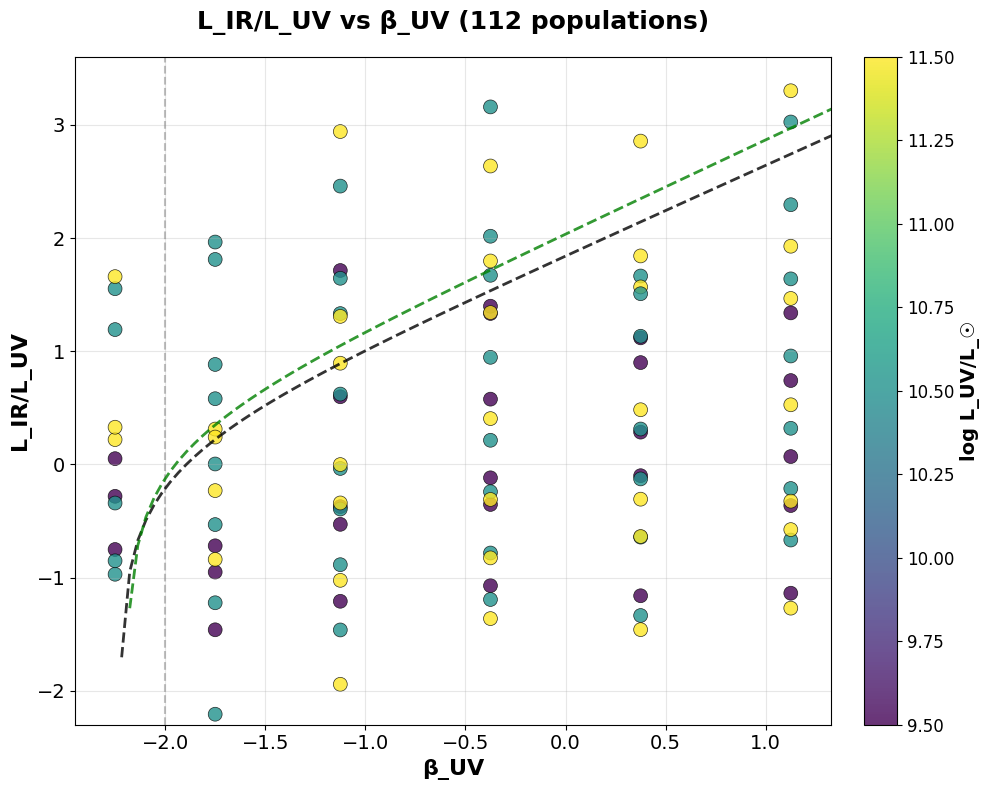

In [19]:
fig = create_lir_luv_beta_plot(wrapper, color_by='l_uv')

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 112 detected populations
📊 Found 112 populations with β_UV and L_UV data

📈 Plot Summary:
   β_UV range: -2.25 to 1.12
   L_UV range: 9.50 to 11.50
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: -1.33e+01 to 3.30e+00
   Median L_IR/L_UV: 2.69e-02
   Colored by: redshift
   L_UV averaging: OFF


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_33529/4173871547.py:299: RuntimeWarning: invalid value encountered in log10
  irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1) + 0.076
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_33529/4173871547.py:301: RuntimeWarning: invalid value encountered in log10
  irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1) + 0.225


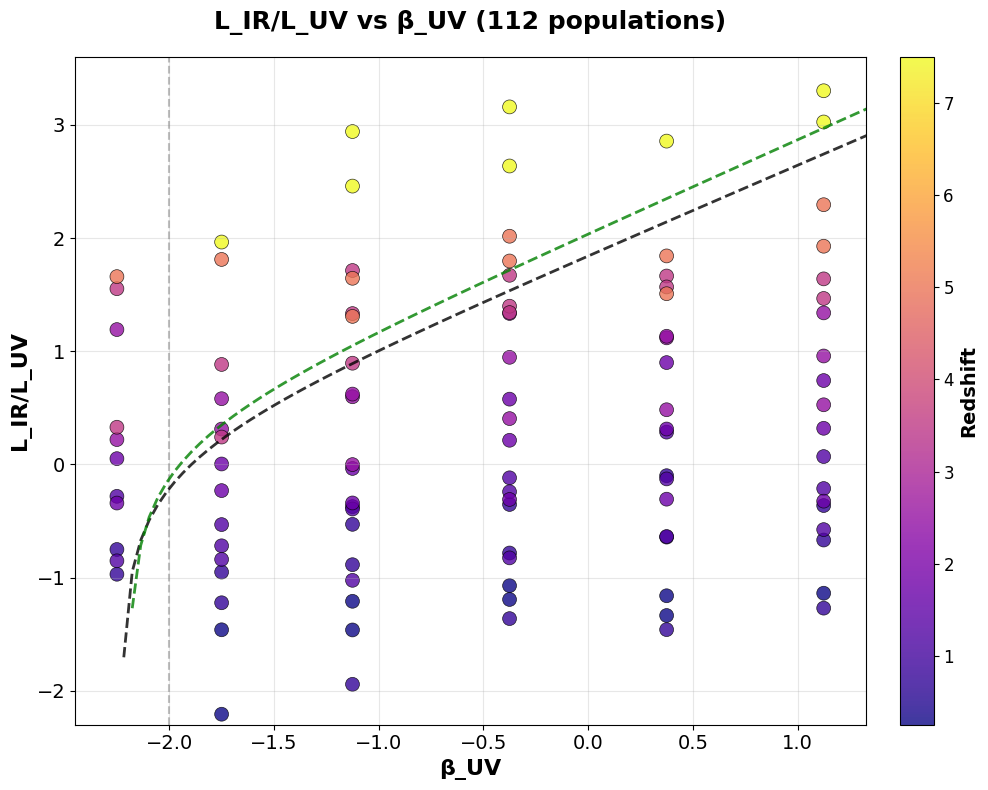

In [16]:
lir_luv_beta = create_lir_luv_beta_plot(wrapper)

In [20]:
def create_lir_luv_beta_plot(wrapper, 
                              show_errors=True,
                              figsize=(8, 7),
                              color_by='redshift',
                              average_luv_per_z=True,
                              save_path=None):
    """
    Create L_IR/L_UV vs β_UV plot from SimstackWrapper results
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with stacking_results and processed_results
    show_errors : bool
        Whether to show error bars
    figsize : tuple
        Figure size (width, height)
    color_by : str
        What to color points by: 'redshift' (default) or 'l_uv'
    average_luv_per_z : bool
        Whether to average L_UV bins within each redshift bin
    save_path : str or Path or None
        Path to save the figure (PDF, PNG, etc. based on extension)
    """
    
    # Get results from wrapper
    if not hasattr(wrapper, 'stacking_results') or wrapper.stacking_results is None:
        print("❌ No stacking results found in wrapper")
        return None
        
    if not hasattr(wrapper, 'processed_results') or wrapper.processed_results is None:
        print("❌ No processed results found in wrapper")
        return None
    
    # Get summary dataframe
    try:
        if hasattr(wrapper.processed_results, 'get_population_summary'):
            summary_df = wrapper.processed_results.get_population_summary()
        else:
            summary_df = wrapper.population_manager.get_population_summary()
        
        print(f"📋 Available columns: {list(summary_df.columns)}")
        
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    # Determine the correct population ID column name
    pop_id_col = None
    possible_id_cols = ['id_label', 'population_id', 'pop_id', 'label']
    
    for col in possible_id_cols:
        if col in summary_df.columns:
            pop_id_col = col
            break
    
    if pop_id_col is None:
        print(f"❌ Could not find population ID column. Available columns: {list(summary_df.columns)}")
        return None
    
    # Filter for detected populations only
    df = summary_df.copy()
    
    # Check if we have L_IR measurements
    lir_cols = [col for col in df.columns if 'ir_luminosity' in col.lower()]
    if not lir_cols:
        print("❌ No L_IR measurements found")
        return None
    
    lir_col = lir_cols[0]
    df = df[df[lir_col] > 0]
    print(f"🔍 Using {lir_col} for L_IR")
    
    if len(df) == 0:
        print("❌ No detected populations found")
        return None
    
    print(f"✅ Found {len(df)} detected populations")
    
    # Parse population information to extract β_UV and L_UV
    def parse_population_id(pop_id):
        """Extract binning information from population ID"""
        try:
            parts = pop_id.split('__')
            bin_info = {}
            
            for part in parts:
                if '_' in part:
                    elements = part.split('_')
                    if len(elements) >= 3:
                        try:
                            min_val = float(elements[-2])
                            max_val = float(elements[-1])
                            bin_name = '_'.join(elements[:-2])
                            bin_info[bin_name] = (min_val, max_val)
                        except ValueError:
                            continue
            
            return bin_info
        except Exception as e:
            print(f"⚠️  Could not parse population ID: {pop_id}")
            return {}
    
    # Parse all population IDs
    parsed_info = df[pop_id_col].apply(parse_population_id)
    
    # Extract β_UV, L_UV, and redshift values
    beta_uv_values = []
    l_uv_values = []
    redshift_values = []
    l_ir_luv_ratios = []
    
    # Color scheme for population types (backup if not using colorbar)
    has_split = any('split' in str(pop_id) for pop_id in df[pop_id_col])
    
    for idx, (_, pop) in enumerate(df.iterrows()):
        pop_id = pop[pop_id_col]
        bin_info = parsed_info.iloc[idx]
        
        # Extract β_UV and redshift from binning
        beta_uv = None
        l_uv = None
        redshift = None
        
        for bin_name, (min_val, max_val) in bin_info.items():
            if 'beta' in bin_name.lower():
                beta_uv = (min_val + max_val) / 2  # Use bin center
            elif 'l_uv' in bin_name.lower() or 'luv' in bin_name.lower():
                l_uv = (min_val + max_val) / 2  # Use bin center
            elif 'redshift' in bin_name.lower() or bin_name.lower() == 'z':
                redshift = (min_val + max_val) / 2  # Use bin center
        
        # Also try to get redshift from median_redshift column
        if redshift is None and 'median_redshift' in pop:
            redshift = pop['median_redshift']
        
        # Get L_IR
        l_ir = pop[lir_col]
        
        # Only include if we have all required values
        if beta_uv is not None and l_uv is not None and l_ir > 0:
            beta_uv_values.append(beta_uv)
            l_uv_values.append(l_uv)
            redshift_values.append(redshift if redshift is not None else np.nan)
            
            # Calculate L_IR/L_UV ratio
            # L_UV is in log space, so convert: L_UV = 10^l_uv
            l_uv_linear = 10**l_uv
            l_ir_luv_ratio = np.log10(l_ir / l_uv_linear)
            l_ir_luv_ratios.append(l_ir_luv_ratio)
    
    if len(beta_uv_values) == 0:
        print("❌ No populations found with both β_UV and L_UV binning")
        return None
    
    print(f"📊 Found {len(beta_uv_values)} populations with β_UV and L_UV data")
    
    # Convert to arrays
    beta_uv_values = np.array(beta_uv_values)
    l_uv_values = np.array(l_uv_values)
    redshift_values = np.array(redshift_values)
    l_ir_luv_ratios = np.array(l_ir_luv_ratios)
    
    # Average L_UV bins per redshift if requested
    if average_luv_per_z and np.any(np.isfinite(redshift_values)):
        print("🔄 Averaging L_UV bins within each redshift bin...")
        
        # Group by redshift and beta_UV bins
        unique_combinations = []
        averaged_data = []
        
        for i, (beta, z) in enumerate(zip(beta_uv_values, redshift_values)):
            if not np.isfinite(z):
                continue
                
            # Round to find matching redshift/beta bins
            z_rounded = round(z, 1)  # Round to 0.1
            beta_rounded = round(beta, 1)  # Round to 0.1
            
            key = (z_rounded, beta_rounded)
            
            # Check if this combination already exists
            found = False
            for j, (existing_key, existing_data) in enumerate(unique_combinations):
                if existing_key == key:
                    # Add to existing group
                    existing_data['l_uv_list'].append(l_uv_values[i])
                    existing_data['l_ir_luv_list'].append(l_ir_luv_ratios[i])
                    found = True
                    break
            
            if not found:
                # Create new group
                unique_combinations.append((key, {
                    'z': z,
                    'beta': beta,
                    'l_uv_list': [l_uv_values[i]],
                    'l_ir_luv_list': [l_ir_luv_ratios[i]]
                }))
        
        # Calculate averages
        if len(unique_combinations) > 0:
            beta_uv_values_avg = []
            l_uv_values_avg = []
            redshift_values_avg = []
            l_ir_luv_ratios_avg = []
            
            for (z_rounded, beta_rounded), data in unique_combinations:
                beta_uv_values_avg.append(data['beta'])
                redshift_values_avg.append(data['z'])
                l_uv_values_avg.append(np.mean(data['l_uv_list']))
                l_ir_luv_ratios_avg.append(np.mean(data['l_ir_luv_list']))
            
            # Replace with averaged values
            beta_uv_values = np.array(beta_uv_values_avg)
            l_uv_values = np.array(l_uv_values_avg)
            redshift_values = np.array(redshift_values_avg)
            l_ir_luv_ratios = np.array(l_ir_luv_ratios_avg)
            
            print(f"✅ Averaged to {len(beta_uv_values)} unique redshift/β_UV combinations")
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Determine what to color by
    if color_by == 'l_uv':
        color_values = l_uv_values
        color_label = 'log L_UV/L_☉'
        cmap = 'viridis'
    else:  # default to redshift
        color_values = redshift_values
        color_label = 'Redshift'
        cmap = 'plasma'
    
    # Check if we have valid color values
    valid_color_mask = np.isfinite(color_values)
    if not np.any(valid_color_mask):
        print(f"⚠️  No valid {color_by} values found, using default colors")
        # Fall back to discrete colors
        scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                            c='blue', s=100, alpha=0.8, 
                            edgecolors='black', linewidth=0.5)
        colorbar_created = False
    else:
        # Use colormap - but be careful with color values
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize
        
        # Only use valid points for colormap normalization
        valid_color_values = color_values[valid_color_mask]
        norm = Normalize(vmin=np.min(valid_color_values), vmax=np.max(valid_color_values))
        
        # Plot points with colormap - use scalar values, not arrays
        scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                            c=color_values, cmap=cmap, s=100, alpha=0.8, 
                            edgecolors='black', linewidth=0.5, norm=norm)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(color_label, fontsize=14, fontweight='bold')
        cbar.ax.tick_params(labelsize=12)
        colorbar_created = True
    
    # Set labels and scale
    ax.set_xlabel('β_UV', fontsize=16, fontweight='bold')
    ax.set_ylabel('L_IR/L_UV', fontsize=16, fontweight='bold')
    #ax.set_yscale('log')
    ax.set_ylim(np.log10([5e-3,2e3]))
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add title
    title = f"L_IR/L_UV vs β_UV ({len(beta_uv_values)} populations)"
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Add legend for population types if we have them and not using colorbar
    if has_split and not colorbar_created:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='red', alpha=0.6, label='Star-forming'),
                          Patch(facecolor='teal', alpha=0.6, label='Quiescent')]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True,
                 title='Population Type', title_fontsize=12)
    
    # Set reasonable limits
    ax.set_xlim(np.min(beta_uv_values) - 0.2, np.max(beta_uv_values) + 0.2)
    
    # Add some reference lines if useful
    if np.min(beta_uv_values) < -1 and np.max(beta_uv_values) > 0:
        ax.axvline(x=-2.0, color='gray', linestyle='--', alpha=0.5, label='β_UV = -2.0 (typical)')
    
    # Literature relations
    beta_model = np.linspace(-2.5, 1.5, 100)
    irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1) + 0.076
    #ax.plot(beta_model, irx_meurer, 'k--', linewidth=2, alpha=0.8, label='Meurer+99')
    irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1) + 0.225
    ax.plot(beta_model, irx_overzier, 'k--', linewidth=2, alpha=0.8, label='Overzier+11')
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Figure saved to: {save_path}")
            
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    # Print summary
    print(f"\n📈 Plot Summary:")
    print(f"   β_UV range: {np.min(beta_uv_values):.2f} to {np.max(beta_uv_values):.2f}")
    print(f"   L_UV range: {np.min(l_uv_values):.2f} to {np.max(l_uv_values):.2f}")
    if np.any(valid_color_mask):
        print(f"   {color_label} range: {np.min(valid_color_values):.2f} to {np.max(valid_color_values):.2f}")
    print(f"   L_IR/L_UV range: {np.min(l_ir_luv_ratios):.2e} to {np.max(l_ir_luv_ratios):.2e}")
    print(f"   Median L_IR/L_UV: {np.median(l_ir_luv_ratios):.2e}")
    print(f"   Colored by: {color_by}")
    if average_luv_per_z:
        print(f"   L_UV values averaged within redshift/β_UV bins")
    
    return fig

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 112 detected populations
📊 Found 112 populations with β_UV and L_UV data
🔄 Averaging L_UV bins within each redshift bin...
✅ Averaged to 48 unique redshift/β_UV combinations


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_33529/1660546822.py:293: RuntimeWarning: invalid value encountered in log10
  irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1) + 0.076
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_33529/1660546822.py:295: RuntimeWarning: invalid value encountered in log10
  irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1) + 0.225


💾 Figure saved to: /Users/mviero/Desktop/IRX-binned.png

📈 Plot Summary:
   β_UV range: -2.25 to 1.12
   L_UV range: 9.50 to 11.50
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: -1.01e+01 to 3.16e+00
   Median L_IR/L_UV: 2.27e-02
   Colored by: redshift
   L_UV values averaged within redshift/β_UV bins


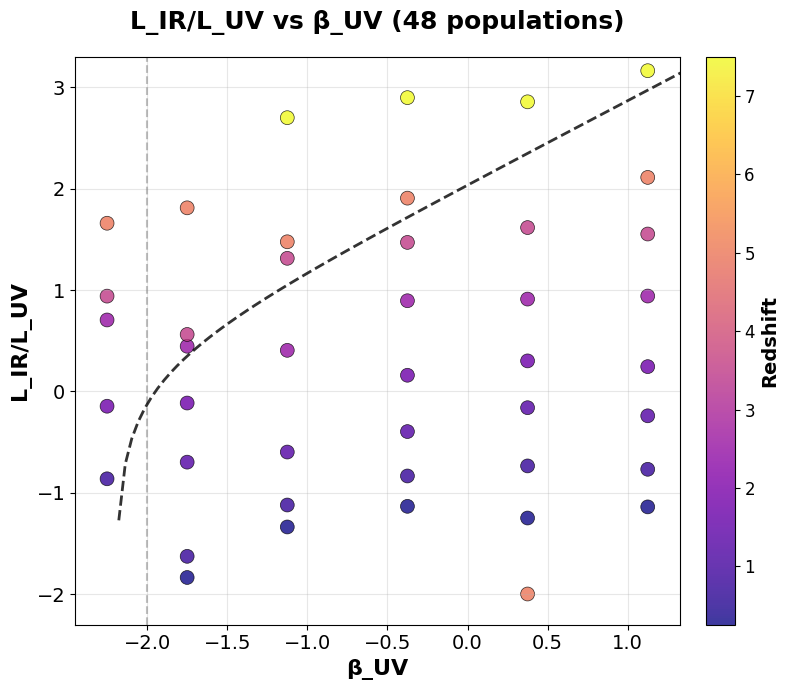

In [21]:
fig = create_lir_luv_beta_plot(
    wrapper, 
    color_by='redshift', 
    average_luv_per_z=True,
    save_path='/Users/mviero/Desktop/IRX-binned.png'
)